# Data Preprocessing dan Ekstraksi Fitur (Interpolasi Polinomial)

## Preprocessing: Penanganan Outlier dan Interpolasi Polinomial

Notebook `Data/polutan/polutan_polinomial.ipynb` memproses data harian untuk tiga polutan di wilayah Widang: karbon monoksida (CO), sulfur dioksida (SO2), dan nitrogen dioksida (NO2). Data masukan berasal dari `CO_Timeseries.csv`, `SO2_Timeseries.csv`, dan `NO2_Timeseries.csv` di folder `Data/Polutan/`. Setiap berkas mempunyai kolom `date` dan satu kolom konsentrasi polutan.

Outlier ditentukan dengan metode Rentang Interkuartil (IQR). Nilai yang berada di bawah `Q1 - 1.5 * IQR` atau di atas `Q3 + 1.5 * IQR` ditandai sebagai nilai kosong (`NaN`). Notebook kemudian menghitung ulang batas IQR dan mengulang penandaan serta imputasi sampai tidak ada lagi nilai yang dianggap outlier.

Untuk mengisi nilai kosong, notebook menggunakan `interpolate(method='polynomial', order=1)`, kemudian `bfill()` dan `ffill()` untuk menangani nilai kosong di tepi deret. Dengan `order=1`, polinomialnya berderajat satu; interpolasi ini berupa garis lurus terhadap indeks baris. Ini berbeda dari `method='time'`, yang mempertimbangkan jarak waktu pada indeks datetime.

Hasil IQR awal yang tercatat pada output notebook adalah 6 outlier untuk CO, 17 untuk SO2, dan 2 untuk NO2. Hasil tersebut adalah hitungan sebelum proses iteratif. Berkas deret waktu yang tersedia masing-masing memiliki 366 baris dengan tanggal dari `2025-08-30` hingga `2026-08-30`.

### 1. Karbon Monoksida (CO)

Muat data CO, urutkan berdasarkan tanggal, ubah konsentrasi menjadi numerik, lalu hitung dan visualisasikan batas IQR:

Jumlah Outlier CO (IQR): 6


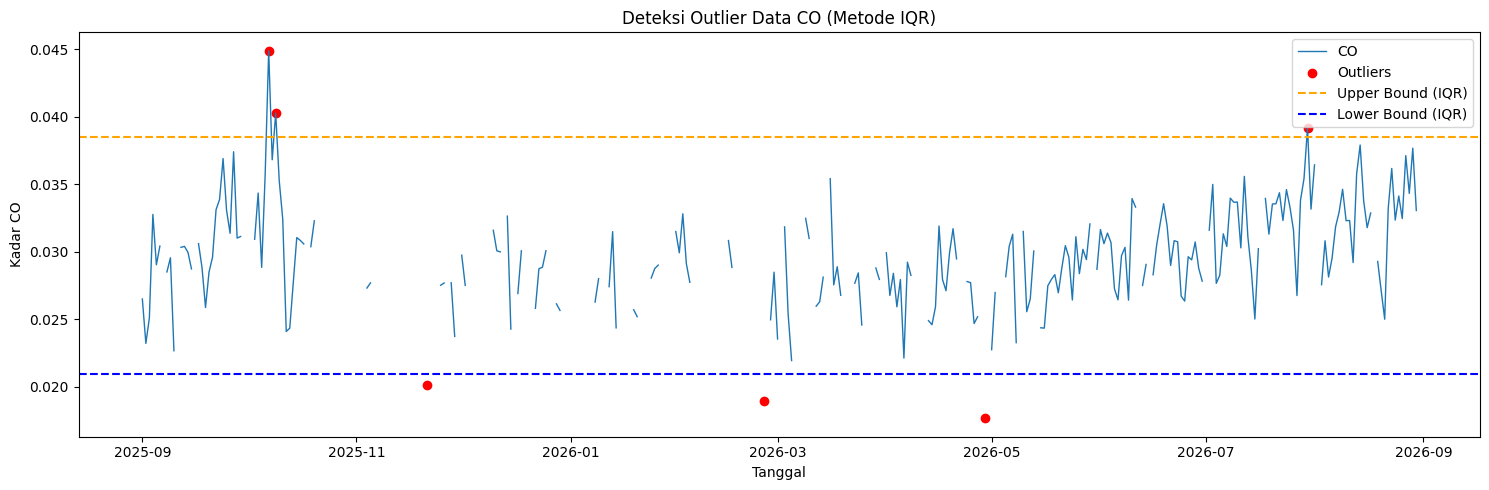

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../../Data/Polutan/CO_Timeseries.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
df["CO"] = pd.to_numeric(df["CO"], errors="coerce")

Q1 = df["CO"].quantile(0.25)
Q3 = df["CO"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df["CO"] < lower_bound) | (df["CO"] > upper_bound)]
print("Jumlah Outlier CO (IQR):", len(outliers_iqr))

plt.figure(figsize=(15, 5))
plt.plot(df["date"], df["CO"], label="CO", linewidth=1)
plt.scatter(
    outliers_iqr["date"],
    outliers_iqr["CO"],
    color="red",
    marker="o",
    label="Outliers",
)
plt.axhline(upper_bound, color="orange", linestyle="dashed", label="Upper Bound (IQR)")
plt.axhline(lower_bound, color="blue", linestyle="dashed", label="Lower Bound (IQR)")
plt.title("Deteksi Outlier Data CO (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar CO")
plt.legend()
plt.tight_layout()
plt.show()

Penanganan outlier dilakukan berulang. Hasilnya disimpan ke `CO_Filled_Polynomial.csv`:

In [2]:
df["CO_filled"] = df["CO"].copy()

while True:
    Q1 = df["CO_filled"].quantile(0.25)
    Q3 = df["CO_filled"].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (df["CO_filled"] < lower_bound) | (df["CO_filled"] > upper_bound)
    if not outliers.any():
        break

    df["CO_filled"] = df["CO_filled"].mask(outliers)
    df["CO_filled"] = (
        df["CO_filled"].interpolate(method="polynomial", order=1).bfill().ffill()
    )

df_co = pd.DataFrame({"date": df["date"], "CO": df["CO_filled"]})
df_co.to_csv("../../Data/Polutan/CO_Filled_Polynomial.csv", index=False)
print("Data CO berhasil diproses dan disimpan ke CO_Filled_Polynomial.csv")

Data CO berhasil diproses dan disimpan ke CO_Filled_Polynomial.csv


### 2. Sulfur Dioksida (SO2)

Langkah yang sama diterapkan pada SO2. Perhitungan IQR awal dan visualisasi outlier:

Jumlah Outlier SO2 (IQR): 17


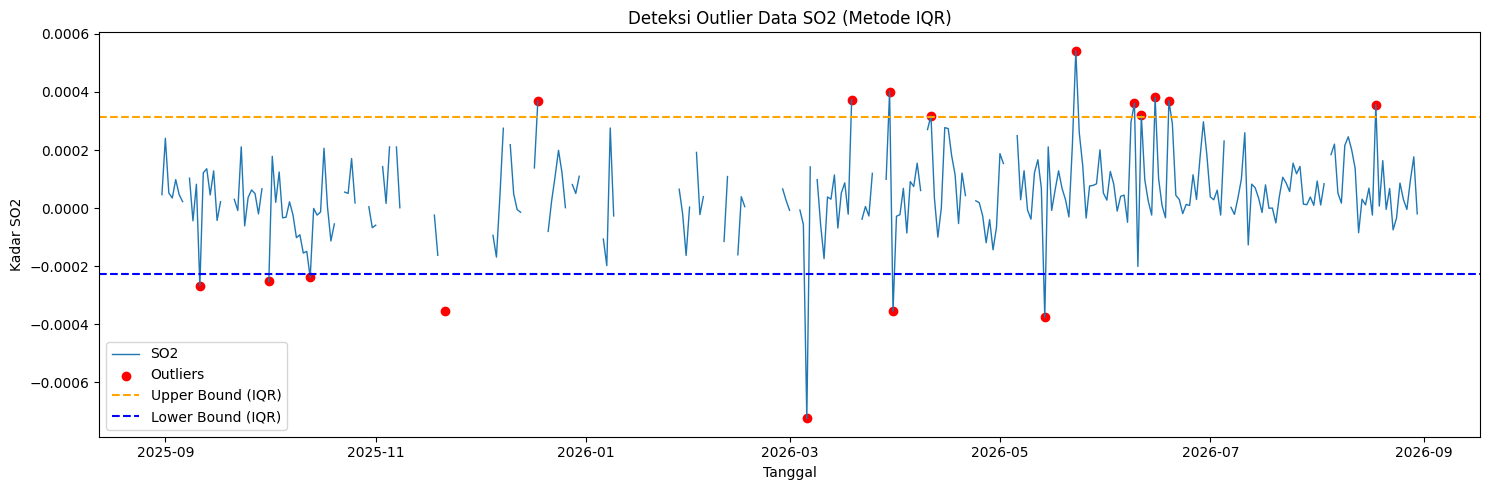

In [3]:
df = pd.read_csv("../../Data/Polutan/SO2_Timeseries.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
df["SO2"] = pd.to_numeric(df["SO2"], errors="coerce")

Q1 = df["SO2"].quantile(0.25)
Q3 = df["SO2"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df["SO2"] < lower_bound) | (df["SO2"] > upper_bound)]
print("Jumlah Outlier SO2 (IQR):", len(outliers_iqr))

plt.figure(figsize=(15, 5))
plt.plot(df["date"], df["SO2"], label="SO2", linewidth=1)
plt.scatter(
    outliers_iqr["date"],
    outliers_iqr["SO2"],
    color="red",
    marker="o",
    label="Outliers",
)
plt.axhline(upper_bound, color="orange", linestyle="dashed", label="Upper Bound (IQR)")
plt.axhline(lower_bound, color="blue", linestyle="dashed", label="Lower Bound (IQR)")
plt.title("Deteksi Outlier Data SO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar SO2")
plt.legend()
plt.tight_layout()
plt.show()

Penanganan outlier iteratif dan penyimpanan hasil:

In [4]:
df["SO2_filled"] = df["SO2"].copy()

while True:
    Q1 = df["SO2_filled"].quantile(0.25)
    Q3 = df["SO2_filled"].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (df["SO2_filled"] < lower_bound) | (df["SO2_filled"] > upper_bound)
    if not outliers.any():
        break

    df["SO2_filled"] = df["SO2_filled"].mask(outliers)
    df["SO2_filled"] = (
        df["SO2_filled"].interpolate(method="polynomial", order=1).bfill().ffill()
    )

df_so2 = pd.DataFrame({"date": df["date"], "SO2": df["SO2_filled"]})
df_so2.to_csv("../../Data/Polutan/SO2_Filled_Polynomial.csv", index=False)
print("Data SO2 berhasil diproses dan disimpan ke SO2_Filled_Polynomial.csv")

Data SO2 berhasil diproses dan disimpan ke SO2_Filled_Polynomial.csv


### 3. Nitrogen Dioksida (NO2)

Perhitungan IQR awal dan visualisasi outlier NO2:

Jumlah Outlier NO2 (IQR): 2


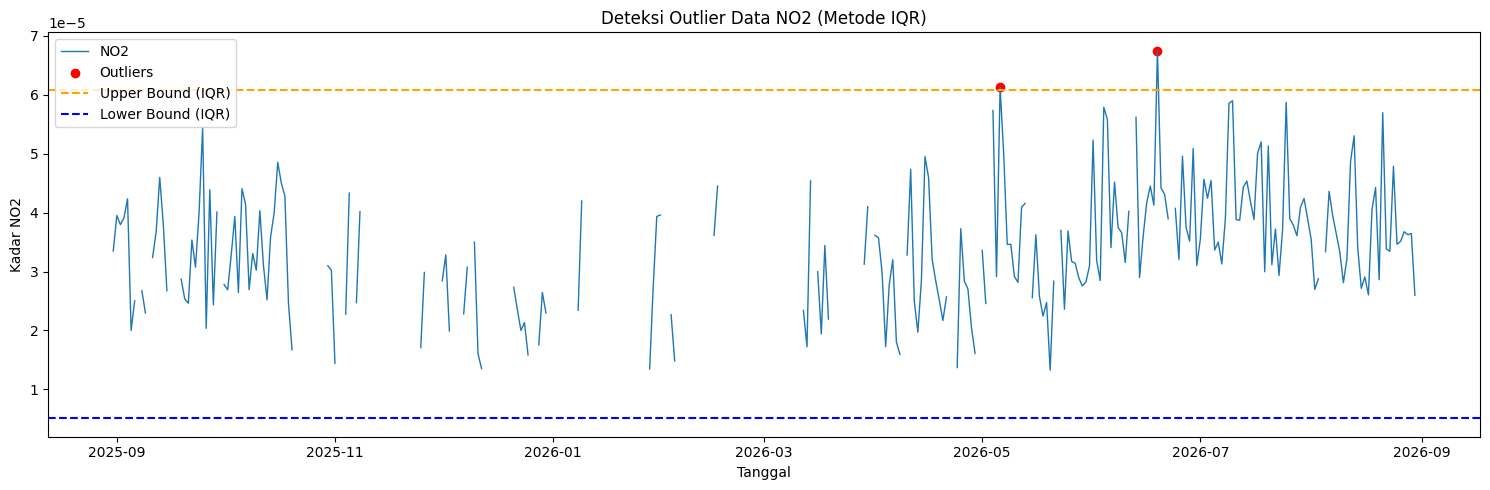

In [5]:
df = pd.read_csv("../../Data/Polutan/NO2_Timeseries.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
df["NO2"] = pd.to_numeric(df["NO2"], errors="coerce")

Q1 = df["NO2"].quantile(0.25)
Q3 = df["NO2"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df["NO2"] < lower_bound) | (df["NO2"] > upper_bound)]
print("Jumlah Outlier NO2 (IQR):", len(outliers_iqr))

plt.figure(figsize=(15, 5))
plt.plot(df["date"], df["NO2"], label="NO2", linewidth=1)
plt.scatter(
    outliers_iqr["date"],
    outliers_iqr["NO2"],
    color="red",
    marker="o",
    label="Outliers",
)
plt.axhline(upper_bound, color="orange", linestyle="dashed", label="Upper Bound (IQR)")
plt.axhline(lower_bound, color="blue", linestyle="dashed", label="Lower Bound (IQR)")
plt.title("Deteksi Outlier Data NO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.show()

Penanganan outlier iteratif dan penyimpanan hasil:

In [6]:
df["NO2_filled"] = df["NO2"].copy()

while True:
    Q1 = df["NO2_filled"].quantile(0.25)
    Q3 = df["NO2_filled"].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (df["NO2_filled"] < lower_bound) | (df["NO2_filled"] > upper_bound)
    if not outliers.any():
        break

    df["NO2_filled"] = df["NO2_filled"].mask(outliers)
    df["NO2_filled"] = (
        df["NO2_filled"].interpolate(method="polynomial", order=1).bfill().ffill()
    )

df_no2 = pd.DataFrame({"date": df["date"], "NO2": df["NO2_filled"]})
df_no2.to_csv("../../Data/Polutan/NO2_Filled_Polynomial.csv", index=False)
print("Data NO2 berhasil diproses dan disimpan ke NO2_Filled_Polynomial.csv")

Data NO2 berhasil diproses dan disimpan ke NO2_Filled_Polynomial.csv


### 4. Visualisasi Gabungan Setelah Preprocessing

Notebook membaca ketiga berkas hasil dan menampilkan kadar polutan sebagai subplot serta grafik overlay. Grafik overlay membantu membandingkan pola perubahan, tetapi skala masing-masing polutan dapat berbeda.

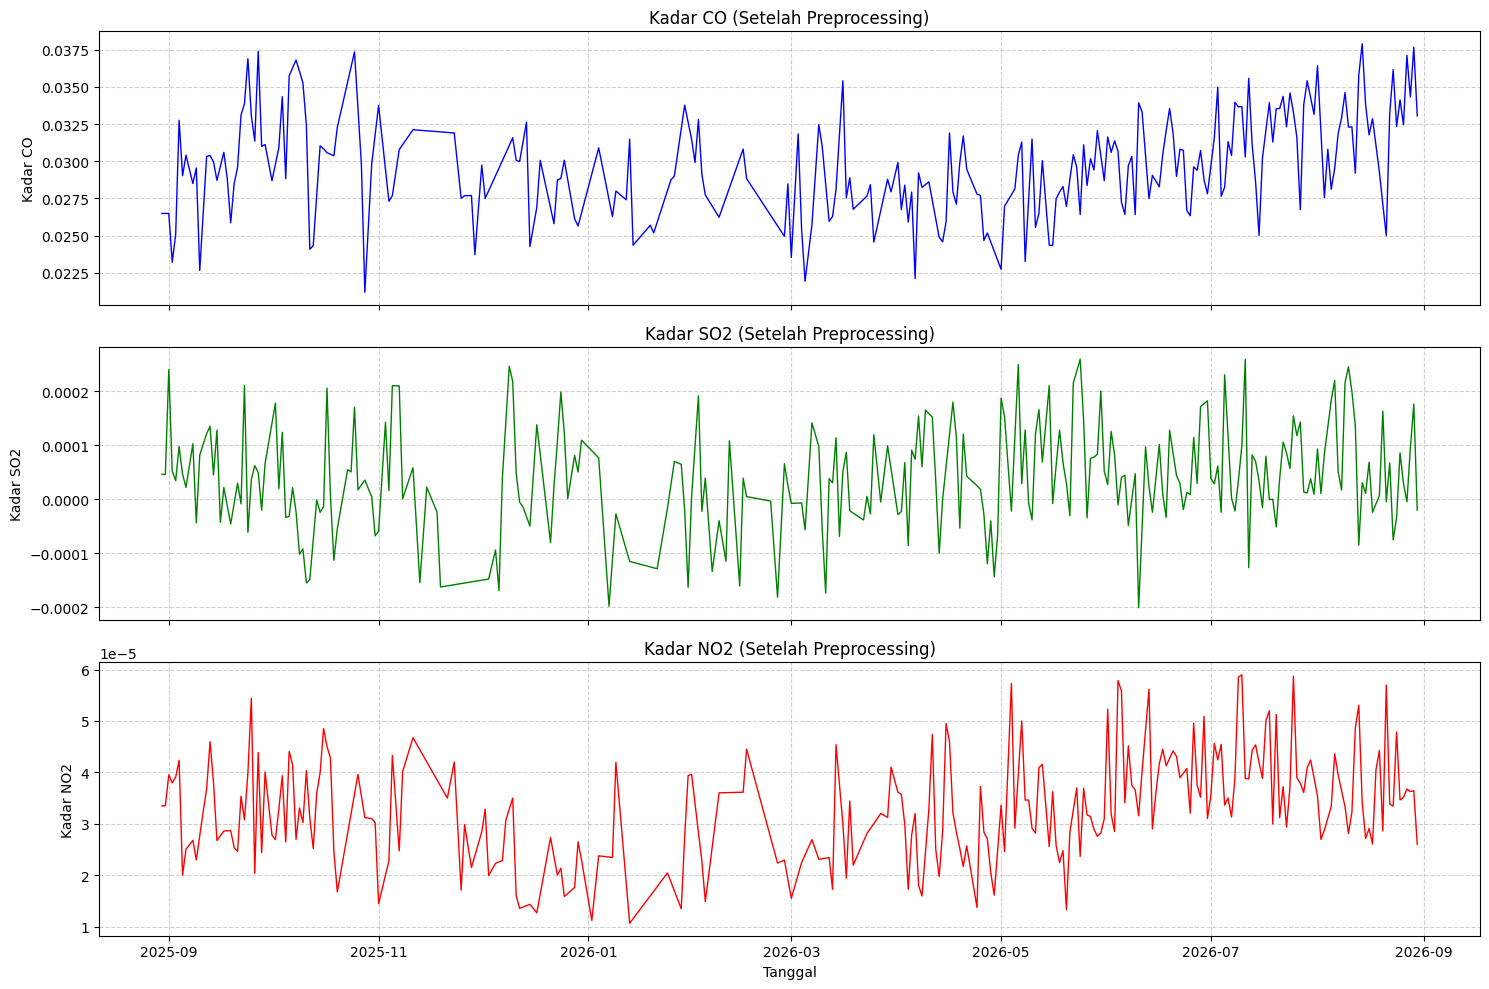

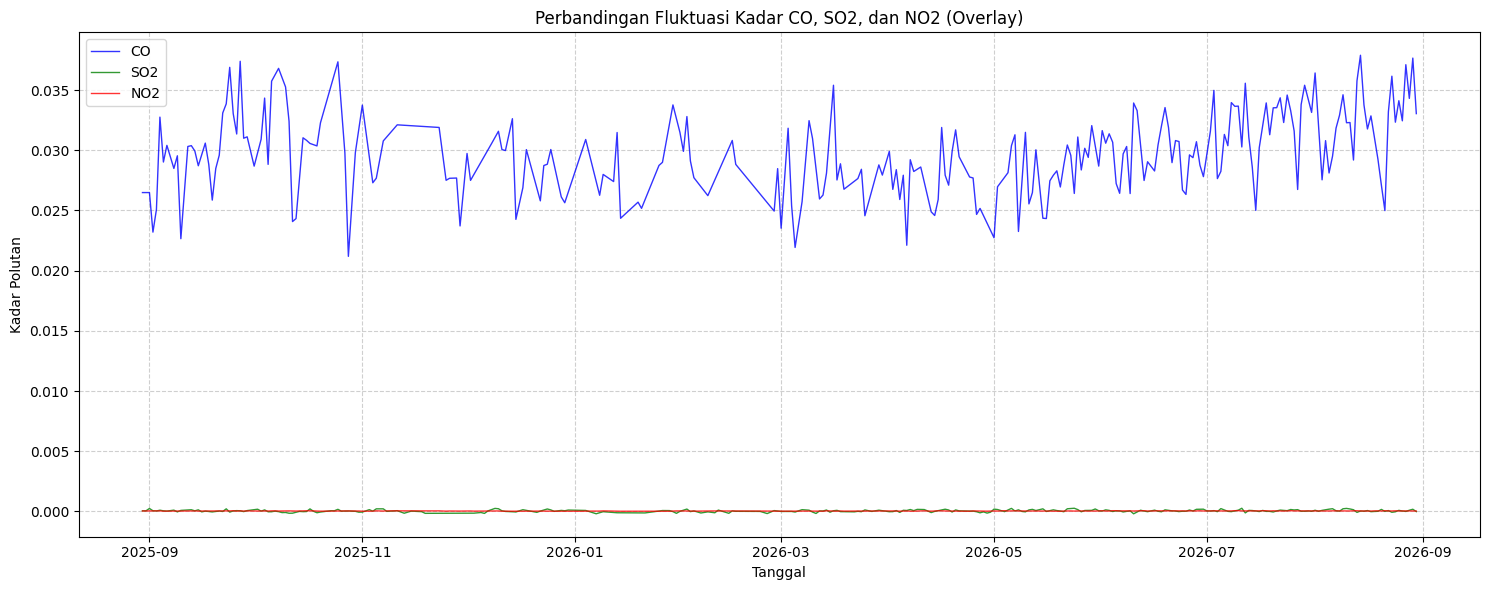

In [7]:
df_co = pd.read_csv("../../Data/Polutan/CO_Filled_Polynomial.csv")
df_so2 = pd.read_csv("../../Data/Polutan/SO2_Filled_Polynomial.csv")
df_no2 = pd.read_csv("../../Data/Polutan/NO2_Filled_Polynomial.csv")

df_co["date"] = pd.to_datetime(df_co["date"])
df_so2["date"] = pd.to_datetime(df_so2["date"])
df_no2["date"] = pd.to_datetime(df_no2["date"])

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
axes[0].plot(df_co["date"], df_co["CO"], color="blue", linewidth=1)
axes[0].set_title("Kadar CO (Setelah Preprocessing)")
axes[0].set_ylabel("Kadar CO")
axes[0].grid(True, linestyle="--", alpha=0.6)

axes[1].plot(df_so2["date"], df_so2["SO2"], color="green", linewidth=1)
axes[1].set_title("Kadar SO2 (Setelah Preprocessing)")
axes[1].set_ylabel("Kadar SO2")
axes[1].grid(True, linestyle="--", alpha=0.6)

axes[2].plot(df_no2["date"], df_no2["NO2"], color="red", linewidth=1)
axes[2].set_title("Kadar NO2 (Setelah Preprocessing)")
axes[2].set_xlabel("Tanggal")
axes[2].set_ylabel("Kadar NO2")
axes[2].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 6))
plt.plot(df_co["date"], df_co["CO"], color="blue", label="CO", linewidth=1, alpha=0.8)
plt.plot(df_so2["date"], df_so2["SO2"], color="green", label="SO2", linewidth=1, alpha=0.8)
plt.plot(df_no2["date"], df_no2["NO2"], color="red", label="NO2", linewidth=1, alpha=0.8)
plt.title("Perbandingan Fluktuasi Kadar CO, SO2, dan NO2 (Overlay)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar Polutan")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### 5. Penggabungan Dataset Polutan

Sebelum ekstraksi fitur, data hasil preprocessing digabung menjadi satu tabel. Berkas gabungan `Polutan_Widang_polynomial.csv` memiliki kolom `date`, `CO`, `NO2`, dan `SO2`.

In [8]:
df_co = pd.read_csv("../../Data/Polutan/CO_Filled_Polynomial.csv")
df_no2 = pd.read_csv("../../Data/Polutan/NO2_Filled_Polynomial.csv")
df_so2 = pd.read_csv("../../Data/Polutan/SO2_Filled_Polynomial.csv")

dataframe_merged = pd.DataFrame(
    {
        "date": df_no2["date"],
        "CO": df_co["CO"],
        "NO2": df_no2["NO2"],
        "SO2": df_so2["SO2"],
    }
)

dataframe_merged.to_csv(
    "../../Data/Polutan/Polutan_Widang_polynomial.csv",
    index=False,
)
print("Data polutan berhasil digabungkan dan disimpan ke Polutan_Widang_polynomial.csv")

Data polutan berhasil digabungkan dan disimpan ke Polutan_Widang_polynomial.csv


## Ekstraksi Fitur Deret Waktu (TSFEL)

Notebook membaca dataset gabungan dan mengekstrak 68 fitur TSFEL untuk setiap polutan. Sebelum ekstraksi, nilai di luar batas IQR kembali ditandai sebagai `NaN` sebagai pemeriksaan tambahan. Pada tahap tambahan ini, notebook mengisi kekosongan dengan `interpolate(method='time')`, `ffill()`, dan `bfill()`; metode ini berbeda dari interpolasi polinomial orde satu yang digunakan pada preprocessing di atas.

Nama setiap fitur diberi awalan nama polutan. Dengan tiga polutan dan 68 fitur per polutan, keluaran yang diharapkan adalah satu baris dengan 204 kolom, yang disimpan ke `Widang_Polynomial.csv`.

In [9]:
import inspect
import tsfel.feature_extraction.features as tsfel_features

df = pd.read_csv("../../Data/Polutan/Polutan_Widang_polynomial.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

pollutants = ["NO2", "SO2", "CO"]
fs = 1

FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()


def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


combined_row = {}
for pollutant in pollutants:
    df_poly = df[["date", pollutant]].copy()
    df_poly[pollutant] = pd.to_numeric(df_poly[pollutant], errors="coerce")

    Q1 = df_poly[pollutant].quantile(0.25)
    Q3 = df_poly[pollutant].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_poly.loc[
        (df_poly[pollutant] < lower_bound)
        | (df_poly[pollutant] > upper_bound),
        pollutant,
    ] = np.nan

    df_clean = df_poly.set_index("date").interpolate(method="time").ffill().bfill()
    signal_1d = df_clean[pollutant].astype(float).values

    for fn_name in FEATURE_LIST:
        feature_key = f"{pollutant}_{fn_name}"
        combined_row[feature_key] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([combined_row])
output_filename = "../../Data/Polutan/Widang_Polynomial.csv"
extracted_features_final.to_csv(output_filename, index=False)
print(f"Total fitur yang dihasilkan: {extracted_features_final.shape[1]}")
print(f"File berhasil disimpan sebagai: {output_filename}")

Total fitur yang dihasilkan: 204
File berhasil disimpan sebagai: ../../Data/Polutan/Widang_Polynomial.csv


Fitur TSFEL di atas mencakup karakteristik statistik, temporal, spektral, dan wavelet. Sebagai contoh, `calc_mean`, `calc_std`, dan `kurtosis` merangkum distribusi; `mean_abs_diff` dan `autocorr` menggambarkan perubahan serta dependensi urutan; fitur `spectral_` dan `wavelet_` meringkas karakteristik frekuensi. Nilai hasil masing-masing polutan dapat dibaca pada kolom dengan awalan seperti `NO2_`, `SO2_`, dan `CO_`.

## Kesimpulan

Alur pengolahan dalam notebook adalah:

1. Membaca deret waktu `CO_Timeseries.csv`, `SO2_Timeseries.csv`, dan `NO2_Timeseries.csv`.
2. Mendeteksi outlier dengan IQR, menandainya sebagai `NaN`, dan mengulang pembersihan dengan interpolasi polinomial orde satu serta `bfill()` dan `ffill()`.
3. Menyimpan hasil tiap polutan sebagai `CO_Filled_Polynomial.csv`, `SO2_Filled_Polynomial.csv`, dan `NO2_Filled_Polynomial.csv`.
4. Menggabungkan ketiga data menjadi `Polutan_Widang_polynomial.csv`.
5. Mengekstrak 68 fitur TSFEL per polutan dan menyimpan hasilnya ke `Widang_Polynomial.csv`.

Interpolasi mengisi nilai pada baris yang tersedia dan tidak menambahkan tanggal kalender yang tidak ada. Untuk analisis yang mensyaratkan jarak harian seragam, kelengkapan dan keteraturan tanggal perlu dipastikan secara terpisah.